# Notebook 01 — VAD & Speech Segmentation

This is the **first stage** of the meeting-transcription pipeline.

### What this notebook does

| Step | Description | Output |
|------|-------------|--------|
| 1 | Load a raw AMI meeting audio (reconstructed from per-utterance clips) | mono 16 kHz waveform |
| 2 | Run **Silero VAD** to classify every frame as speech or silence | raw `(start_s, end_s)` list |
| 3 | Merge short silence gaps between adjacent speech segments | cleaner segment list |
| 4 | Visualise the waveform with speech/silence regions overlaid | matplotlib figure |
| 5 | Quick precision/recall against AMI ground-truth timestamps | numeric stats |
| 6 | Save final segments to disk | `output/vad/EN2001a_vad_segments.json` |

### Context

The AMI IHM data was downloaded and restructured by `download-dataset.ipynb`.
Each meeting was saved as individual utterance WAV files under `output/meetings/<meeting_id>/`.
Since no single continuous headset-mix file is available from the HF version, we **reconstruct** the
full-meeting waveform by placing each utterance clip at its ground-truth timestamp and filling the
gaps with silence.  This gives Silero VAD a realistic signal to work with.

We focus on one meeting — **EN2001a** — and process only the first **5 minutes** to keep the demo fast.


---
## Step 0 — Setup

Install any missing packages and import everything needed by this notebook.
`torch` + `torchaudio` are required by Silero VAD; all others are already in the project dependencies.


In [15]:
# Uncomment and run once if torch / torchaudio are not installed yet:
# %pip install torch torchaudio -q

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import soundfile as sf
from pathlib import Path
from IPython.display import Audio, display


---
## Step 1 — Load & Reconstruct the Meeting Audio

The HuggingFace AMI dataset stores audio as **per-utterance clips**, not as one continuous recording.
To give Silero VAD a realistic signal (alternating speech + silence, just like a real headset-mix), we:

1. Read `transcript.csv` for meeting **EN2001a** — it has each utterance's filename and ground-truth `start_s / end_s`.
2. Allocate a zero-filled array long enough to hold the target duration.
3. For each utterance, decode the WAV file and paste it into the array at its correct time position.

This produces a single 1-D `float32` waveform at 16 kHz — exactly what Silero VAD expects.


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
MEETING_ID     = "EN2001a"
MEETING_DIR    = Path(f"output/meetings/{MEETING_ID}")
TARGET_SR      = 16_000   # Silero VAD requires exactly 16 kHz
AUDIO_DURATION = 300      # seconds of the meeting to reconstruct (5 min demo)

# ── Load transcript (ground-truth timestamps + per-utterance filenames) ────────
df = pd.read_csv(MEETING_DIR / "transcript.csv")

# Keep only utterances that start before our target window
df = df[df["start_s"] < AUDIO_DURATION].copy()

print(f"Meeting      : {MEETING_ID}")
print(f"Window       : 0 – {AUDIO_DURATION}s")
print(f"Utterances   : {len(df)}")
print(f"Speakers     : {df['speaker'].nunique()}  ({sorted(df['speaker'].unique())})")
print()
print(df[["idx", "start_s", "end_s", "speaker", "text"]].head(6).to_string(index=False))


Meeting      : EN2001a
Window       : 0 – 300s
Utterances   : 89
Speakers     : 5  (['FEO065', 'FEO066', 'MEE067', 'MEE068', 'MEO069'])

 idx  start_s  end_s speaker                                                               text
   0     3.34   3.88  MEO069                                                               'KAY
   1     5.57   5.94  MEE068                                                               OKAY
   2     5.60   6.01  MEO069                                                               GOSH
   3    10.48  10.88  MEO069                                                               'KAY
   4    11.09  15.53  MEE068 DOES ANYONE WANT TO SEE UH STEVE'S FEEDBACK FROM THE SPECIFICATION
   5    16.77  18.05  MEO069                                 IS THERE MUCH MORE IN IT THAN HE D


In [3]:
def reconstruct_meeting_audio(utterance_df, meeting_dir, target_sr, duration_s):
    """
    Reconstruct a continuous meeting waveform from individual utterance WAV clips.

    Each clip is read from disk and pasted into a zero-filled output array at
    the position determined by its ground-truth start_s timestamp.  Silence
    between utterances is represented by zeros, which mirrors what a real
    continuous headset-mix recording would contain.

    Parameters
    ----------
    utterance_df : pd.DataFrame
        Rows from transcript.csv.  Must have columns: audio_file, start_s, end_s.
    meeting_dir  : pathlib.Path
        Directory that contains the utt_XXXX.wav files.
    target_sr    : int
        Output sample rate.  Silero VAD requires 16 000 Hz.
        If an individual clip has a different rate it is resampled via librosa.
    duration_s   : float
        Total length of the output waveform in seconds.

    Returns
    -------
    waveform    : np.ndarray  shape (duration_s * target_sr,), dtype float32
    sample_rate : int         always equal to target_sr
    """
    total_samples = int(duration_s * target_sr)
    waveform = np.zeros(total_samples, dtype=np.float32)

    for _, row in utterance_df.iterrows():
        wav_path = meeting_dir / row["audio_file"]
        if not wav_path.exists():
            continue

        audio, sr = sf.read(str(wav_path))

        # Convert stereo to mono by averaging channels
        if audio.ndim > 1:
            audio = audio.mean(axis=1)
        audio = audio.astype(np.float32)

        # Resample only if the file sample rate differs from what we need
        if sr != target_sr:
            import librosa
            audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)

        # Paste the clip into the output array at the correct time position
        start_sample = int(row["start_s"] * target_sr)
        end_sample   = min(start_sample + len(audio), total_samples)
        chunk_len    = end_sample - start_sample
        waveform[start_sample:end_sample] = audio[:chunk_len]

    return waveform, target_sr


# Reconstruct – this reads ~100–200 small WAV files so it takes a few seconds
waveform, sr = reconstruct_meeting_audio(df, MEETING_DIR, TARGET_SR, AUDIO_DURATION)

rms = float(np.sqrt(np.mean(waveform ** 2)))
speech_frac = float(np.mean(waveform != 0.0))

print(f"Waveform shape : {waveform.shape}  ({waveform.shape[0] / sr:.1f}s @ {sr} Hz)")
print(f"RMS amplitude  : {rms:.5f}")
print(f"Non-zero frac  : {speech_frac:.2%}  (rough speech density)")


Waveform shape : (4800000,)  (300.0s @ 16000 Hz)
RMS amplitude  : 0.01263
Non-zero frac  : 85.29%  (rough speech density)


In [5]:
# ── Preview: play the first 60 s of the reconstructed audio ──────────────────
PREVIEW_S = 60
print(f"Playing first {PREVIEW_S}s of reconstructed meeting {MEETING_ID} …")
display(Audio(waveform[:PREVIEW_S * sr], rate=sr))


Playing first 60s of reconstructed meeting EN2001a …


---
## Step 2 — Run Silero VAD

**Silero VAD** is a lightweight neural VAD model trained on hundreds of languages.
It processes audio in small windows (512 samples = 32 ms at 16 kHz) and outputs a speech probability per window.

Key parameters:
| Parameter | Value | Meaning |
|-----------|-------|---------|
| `threshold` | 0.5 | Frames with speech probability ≥ 0.5 are labelled *speech* |
| `min_speech_duration_ms` | 250 | Ignore isolated blips shorter than 250 ms |
| `min_silence_duration_ms` | 100 | Silence gaps shorter than 100 ms are bridged within a segment |

The model is downloaded from Torch Hub on the first run and cached locally.


In [7]:
import torch

# Load Silero VAD v5 from Torch Hub.
# Downloads ~2 MB on the first run, then uses the local cache.
model, utils = torch.hub.load(
    repo_or_dir="snakers4/silero-vad",
    model="silero_vad",
    force_reload=False,
    onnx=False,
    verbose=False,
)
(get_speech_timestamps, _, read_audio, *_) = utils

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print(f"Silero VAD loaded  (running on {device.upper()})")


Downloading: "https://github.com/snakers4/silero-vad/zipball/master" to /Users/dawit/.cache/torch/hub/master.zip
Silero VAD loaded  (running on CPU)


In [8]:
def run_silero_vad(waveform, model, sample_rate=16_000, threshold=0.5):
    """
    Run Silero VAD on a mono float32 waveform and return speech segments.

    Parameters
    ----------
    waveform    : np.ndarray  1-D float32 array at `sample_rate` Hz
    model       : Silero VAD model (from torch.hub)
    sample_rate : int         must be 16 000 (or 8 000) Hz
    threshold   : float       speech-probability cut-off in [0, 1]
                              higher → stricter, fewer segments
                              lower  → more permissive, more segments

    Returns
    -------
    List[dict]  each dict has 'start' and 'end' in **seconds**
    """
    audio_tensor = torch.tensor(waveform).to(device)

    raw = get_speech_timestamps(
        audio_tensor,
        model,
        sampling_rate=sample_rate,
        threshold=threshold,
        min_speech_duration_ms=250,   # discard very short blips
        min_silence_duration_ms=100,  # bridge tiny gaps within a segment
        return_seconds=True,          # get output in seconds, not samples
    )

    return [{"start": float(t["start"]), "end": float(t["end"])} for t in raw]


# Run VAD — typical runtime: < 2 s on CPU for 5 min of audio
VAD_THRESHOLD = 0.5
raw_segments = run_silero_vad(waveform, model, sr, threshold=VAD_THRESHOLD)

print(f"VAD threshold    : {VAD_THRESHOLD}")
print(f"Raw segments     : {len(raw_segments)}")
print(f"\nFirst 10 segments:")
for s in raw_segments[:10]:
    dur = s["end"] - s["start"]
    print(f"  [{s['start']:7.2f}s – {s['end']:7.2f}s]  ({dur:.2f}s)")


VAD threshold    : 0.5
Raw segments     : 88

First 10 segments:
  [  10.60s –   10.90s]  (0.30s)
  [  11.10s –   14.00s]  (2.90s)
  [  14.70s –   15.60s]  (0.90s)
  [  16.80s –   18.80s]  (2.00s)
  [  18.90s –   20.80s]  (1.90s)
  [  21.40s –   22.90s]  (1.50s)
  [  23.00s –   25.50s]  (2.50s)
  [  28.10s –   30.70s]  (2.60s)
  [  32.00s –   32.70s]  (0.70s)
  [  32.90s –   34.30s]  (1.40s)


---
## Step 3 — Merge Short Silence Gaps

Silero VAD may split a single continuous phrase into several segments if there is a
brief pause (breath, hesitation).  For downstream speaker embedding we usually want
one contiguous chunk per "turn", not many tiny fragments.

`merge_segments` iterates through consecutive segments and joins any pair separated
by a silence shorter than `gap_threshold_s`.  Choosing the right threshold is a
trade-off:

- **Too small** → short pauses cause unnecessary splits; same speaker's embedding is computed on tiny clips
- **Too large** → we start bridging across genuine speaker changes

We compare three thresholds below (0.1 s / 0.3 s / 0.5 s) to show the effect.


In [9]:
def merge_segments(segments, gap_threshold_s=0.3):
    """
    Merge consecutive speech segments separated by a short silence gap.

    Short within-utterance pauses (breaths, hesitations) often cause Silero VAD
    to split a single phrase into two adjacent segments.  Bridging gaps shorter
    than `gap_threshold_s` produces cleaner, longer speech chunks that are better
    suited for downstream speaker embedding.

    Parameters
    ----------
    segments        : list[dict]  sorted list of {'start': float, 'end': float}
    gap_threshold_s : float       silence gaps ≤ this value are bridged (seconds)

    Returns
    -------
    list[dict]  merged segments, same format as input
    """
    if not segments:
        return []

    merged = [dict(segments[0])]   # start with a copy of the first segment

    for seg in segments[1:]:
        gap = seg["start"] - merged[-1]["end"]
        if gap <= gap_threshold_s:
            # Gap is short — extend the current segment to absorb the next one
            merged[-1]["end"] = seg["end"]
        else:
            # Gap is large enough to be real silence — start a new segment
            merged.append(dict(seg))

    return merged


# Compare how segment count changes with different thresholds
print(f"{'Threshold':>12}  {'Segments':>9}  {'Avg duration (s)':>18}")
print("-" * 45)
for thr in [0.0, 0.1, 0.3, 0.5, 1.0]:
    m = merge_segments(raw_segments, gap_threshold_s=thr)
    avg_dur = np.mean([s["end"] - s["start"] for s in m]) if m else 0.0
    print(f"{thr:>12.1f}  {len(m):>9}  {avg_dur:>18.2f}")

# Use 0.3 s as the working default — reasonable for meeting speech
MERGE_GAP = 0.3
segments = merge_segments(raw_segments, gap_threshold_s=MERGE_GAP)
print(f"\nWorking default: gap ≤ {MERGE_GAP}s  →  {len(segments)} segments")


   Threshold   Segments    Avg duration (s)
---------------------------------------------
         0.0         88                2.51
         0.1         83                2.67
         0.3         58                3.91
         0.5         34                6.95
         1.0         18               13.81

Working default: gap ≤ 0.3s  →  58 segments


---
## Step 4 — Visualise Waveform with Speech / Silence Regions

The plot shows the reconstructed waveform for the first 60 seconds.

- **Orange shading** — Silero VAD prediction (merged segments)
- **Green shading** — Ground-truth speech regions from `transcript.csv`

Overlap between orange and green → correct detection.  
Orange without green → false alarm.  
Green without orange → missed speech.


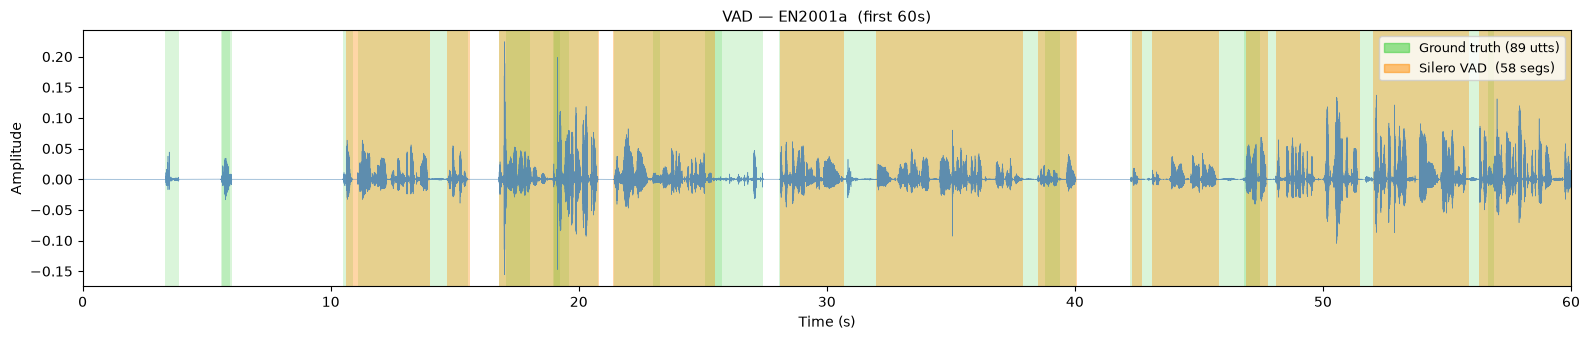

In [10]:
def plot_vad_result(waveform, sr, vad_segments, gt_segments=None,
                    title="", plot_duration_s=60):
    """
    Plot the waveform with VAD speech regions (and optional ground-truth) overlaid.

    Parameters
    ----------
    waveform        : np.ndarray  raw audio samples (float32)
    sr              : int         sample rate
    vad_segments    : list[dict]  Silero VAD output  {'start', 'end'} in seconds
    gt_segments     : list[dict]  ground-truth spans {'start', 'end'} in seconds (optional)
    title           : str         figure title
    plot_duration_s : float       how many seconds of audio to show
    """
    n_samples = int(plot_duration_s * sr)
    time_axis = np.linspace(0, plot_duration_s, n_samples)
    signal    = waveform[:n_samples]

    fig, ax = plt.subplots(figsize=(16, 3.5))
    ax.plot(time_axis, signal, color="steelblue", linewidth=0.4, alpha=0.85)

    # Ground-truth speech spans (green, drawn first so VAD overlay is on top)
    if gt_segments:
        for seg in gt_segments:
            if seg["start"] >= plot_duration_s:
                break
            ax.axvspan(seg["start"], min(seg["end"], plot_duration_s),
                       color="limegreen", alpha=0.18, linewidth=0)

    # Silero VAD segments (orange, semi-transparent)
    for i, seg in enumerate(vad_segments):
        if seg["start"] >= plot_duration_s:
            break
        ax.axvspan(seg["start"], min(seg["end"], plot_duration_s),
                   color="darkorange", alpha=0.35, linewidth=0,
                   label="Silero VAD" if i == 0 else "_")

    # Build a clean legend
    legend_handles = [
        mpatches.Patch(color="darkorange", alpha=0.5, label=f"Silero VAD  ({len(vad_segments)} segs)"),
    ]
    if gt_segments:
        legend_handles.insert(0, mpatches.Patch(color="limegreen", alpha=0.5,
                                                label=f"Ground truth ({len(gt_segments)} utts)"))

    ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
    ax.set_xlabel("Time (s)", fontsize=10)
    ax.set_ylabel("Amplitude", fontsize=10)
    ax.set_title(title or f"VAD — {MEETING_ID}  (first {plot_duration_s}s)", fontsize=11)
    ax.set_xlim(0, plot_duration_s)
    plt.tight_layout()
    plt.show()


# Build ground-truth list from transcript.csv rows
gt_segments = [
    {"start": float(row["start_s"]), "end": float(row["end_s"])}
    for _, row in df.iterrows()
]

plot_vad_result(waveform, sr, segments, gt_segments=gt_segments, plot_duration_s=60)


---
## Step 5 — Quick Evaluation vs Ground Truth

We measure how well the VAD predictions cover the actual speech regions.
Both masks are discretised at **100 ms** resolution (coarse but fast).

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Precision** | TP / (TP + FP) | of predicted speech, how much is really speech |
| **Recall**    | TP / (TP + FN) | of actual speech, how much did VAD catch |
| **F1**        | harmonic mean  | balanced summary |

Note: this is a proxy evaluation — the ground-truth spans in `transcript.csv`
are the annotated utterance boundaries, not a frame-level VAD reference.
True VAD evaluation requires a separate silence-annotated reference, which the
AMI corpus provides separately (not used here for brevity).


In [13]:
def coverage_metrics(pred_segs, gt_segs, total_s, frame_ms=100):
    """
    Compute frame-level precision, recall, and F1 of VAD predictions.

    Both prediction and ground-truth segment lists are converted to binary
    frame masks at `frame_ms` resolution, then compared element-wise.

    Parameters
    ----------
    pred_segs : list[dict]  VAD output   {'start', 'end'} in seconds
    gt_segs   : list[dict]  ground truth {'start', 'end'} in seconds
    total_s   : float       total duration of the audio window
    frame_ms  : int         frame size in milliseconds (resolution of comparison)

    Returns
    -------
    dict  with keys 'precision', 'recall', 'f1', 'speech_ratio_pred',
                    'speech_ratio_gt'
    """
    frames_per_s = 1000 / frame_ms
    n_frames     = int(total_s * frames_per_s)

    pred_mask = np.zeros(n_frames, dtype=bool)
    gt_mask   = np.zeros(n_frames, dtype=bool)

    for seg in pred_segs:
        s = int(seg["start"] * frames_per_s)
        e = min(int(seg["end"]   * frames_per_s), n_frames)
        pred_mask[s:e] = True

    for seg in gt_segs:
        s = int(seg["start"] * frames_per_s)
        e = min(int(seg["end"]   * frames_per_s), n_frames)
        gt_mask[s:e] = True

    tp = int(np.sum( pred_mask &  gt_mask))
    fp = int(np.sum( pred_mask & ~gt_mask))
    fn = int(np.sum(~pred_mask &  gt_mask))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)

    return {
        "precision":        round(precision, 4),
        "recall":           round(recall,    4),
        "f1":               round(f1,        4),
        "speech_ratio_pred": round(pred_mask.mean(), 4),
        "speech_ratio_gt":   round(gt_mask.mean(),   4),
    }


metrics = coverage_metrics(segments, gt_segments, AUDIO_DURATION)

print(f"VAD evaluation — {MEETING_ID}  (first {AUDIO_DURATION}s)")
print(f"  VAD segments  : {len(segments)}")
print(f"  GT utterances : {len(gt_segments)}")
print()
print(f"  Precision     : {metrics['precision']:.3f}")
print(f"  Recall        : {metrics['recall']:.3f}")
print(f"  F1            : {metrics['f1']:.3f}")
print()
print(f"  Speech ratio predicted : {metrics['speech_ratio_pred']:.2%}")
print(f"  Speech ratio ground-truth: {metrics['speech_ratio_gt']:.2%}")


VAD evaluation — EN2001a  (first 300s)
  VAD segments  : 58
  GT utterances : 89

  Precision     : 0.993
  Recall        : 0.856
  F1            : 0.919

  Speech ratio predicted : 75.53%
  Speech ratio ground-truth: 87.57%


---
## Step 6 — Save Segments to Disk

The output of this notebook is consumed by **`02_embeddings.ipynb`**.
We save the final segment list as JSON with enough metadata for the next stage to
reconstruct the exact audio slices without re-running VAD.

Output path: `output/vad/<meeting_id>_vad_segments.json`


In [14]:
VAD_OUTPUT_DIR = Path("output/vad")
VAD_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_record = {
    # Provenance — lets the next notebook know exactly what produced this file
    "meeting_id":       MEETING_ID,
    "audio_duration_s": AUDIO_DURATION,
    "sample_rate":      sr,
    # VAD parameters (reproducibility)
    "vad_threshold":    VAD_THRESHOLD,
    "merge_gap_s":      MERGE_GAP,
    # Results
    "num_segments":     len(segments),
    "vad_metrics":      metrics,
    # The actual segments — downstream consumers only need start/end
    "segments": [
        {"start": round(s["start"], 3), "end": round(s["end"], 3)}
        for s in segments
    ],
}

out_path = VAD_OUTPUT_DIR / f"{MEETING_ID}_vad_segments.json"
with open(out_path, "w", encoding="utf-8") as fh:
    json.dump(output_record, fh, indent=2)

print(f"Saved {len(segments)} segments  →  {out_path.resolve()}")
print()
print("Preview (first 5 segments):")
for s in segments[:5]:
    dur = s["end"] - s["start"]
    print(f"  {s['start']:7.2f}s – {s['end']:7.2f}s   ({dur:.2f}s)")


Saved 58 segments  →  /Users/dawit/projects/speech-meeting-transcriptin/output/vad/EN2001a_vad_segments.json

Preview (first 5 segments):
    10.60s –   14.00s   (3.40s)
    14.70s –   15.60s   (0.90s)
    16.80s –   20.80s   (4.00s)
    21.40s –   25.50s   (4.10s)
    28.10s –   30.70s   (2.60s)
